In [1]:
import torch
import torch.nn.functional as F

import random

# Data preparation

In [2]:
names = []
with open("./data/names.txt", "r") as f:
    for line in f:
        names.append(line.rstrip())

len(names)

32033

In [3]:
import random

random.seed(22334455)
random.shuffle(names)

In [4]:
names[:10]

['maitreya',
 'nakari',
 'kalessi',
 'elex',
 'jacinda',
 'skylor',
 'adalae',
 'kenn',
 'ephram',
 'capri']

In [5]:
alphabet = '.' + "".join(sorted(set("".join(names))))
alphabet

'.abcdefghijklmnopqrstuvwxyz'

In [6]:
alphabet_len = len(alphabet)

In [7]:
char_to_idx = {}
for idx, char in enumerate(alphabet):
    char_to_idx[char] = idx

char_to_idx

{'.': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [8]:
def create_data_sample(word, prefix_len):
    X = []
    Y = []
    
    prefix = [char_to_idx['.']] * prefix_len
    for char in word + '.':
        X.append(prefix)
        idx = char_to_idx[char]
        Y.append(idx)

        prefix = prefix[1:] + [idx]

    return X, Y

In [9]:
def index_to_word(indexes):
    return "".join(alphabet[idx] for idx in indexes)

In [10]:
def print_data(data):
    X, Y = data

    for x, y in zip(X, Y):
        prefix = index_to_word(x)

        print(f"{prefix} --> {alphabet[y]}")
        
data = create_data_sample("rahul", 3)
print_data(data)

... --> r
..r --> a
.ra --> h
rah --> u
ahu --> l
hul --> .


In [11]:
num_prefix_chars = 5

def create_dataset(words, prefix_len):
    X = []
    Y = []

    for word in words:
        x, y = create_data_sample(word, prefix_len)

        X += x
        Y += y

    return X, Y

In [12]:
def print_dataset(data, labels):
    for d, l in zip(data, labels):
        print(f"{index_to_word(d)} --> {alphabet[l]}")

In [13]:
print_dataset(*create_dataset(names[:3], 3))

... --> m
..m --> a
.ma --> i
mai --> t
ait --> r
itr --> e
tre --> y
rey --> a
eya --> .
... --> n
..n --> a
.na --> k
nak --> a
aka --> r
kar --> i
ari --> .
... --> k
..k --> a
.ka --> l
kal --> e
ale --> s
les --> s
ess --> i
ssi --> .


In [14]:
training_set_size = int(0.8 * len(names))
dev_set_size = int(0.1 * len(names))

training_set = names[:training_set_size]
dev_set = names[training_set_size:training_set_size + dev_set_size]
test_set = names[training_set_size + dev_set_size:]

print(len(training_set), len(dev_set), len(test_set))

25626 3203 3204


In [15]:
train_data, train_labels = create_dataset(training_set, num_prefix_chars)
dev_data, dev_labels = create_dataset(dev_set, num_prefix_chars)
test_data, test_labels = create_dataset(test_set, num_prefix_chars)

In [16]:
print("\n--- TRAIN ---")
print_dataset(train_data[:10], train_labels[:10])
print("\n--- DEV ---")
print_dataset(dev_data[:10], dev_labels[:10])
print("\n--- TEST ---")
print_dataset(test_data[:10], test_labels[:10])


--- TRAIN ---
..... --> m
....m --> a
...ma --> i
..mai --> t
.mait --> r
maitr --> e
aitre --> y
itrey --> a
treya --> .
..... --> n

--- DEV ---
..... --> z
....z --> v
...zv --> i
..zvi --> .
..... --> m
....m --> a
...ma --> n
..man --> u
.manu --> e
manue --> l

--- TEST ---
..... --> e
....e --> m
...em --> b
..emb --> y
.emby --> r
embyr --> .
..... --> c
....c --> r
...cr --> a
..cra --> w


In [17]:
assert len(train_data) == len(train_labels)
assert len(dev_data) == len(dev_labels)
assert len(test_data) == len(test_labels)

In [18]:
train_data = torch.tensor(train_data)
train_labels = torch.tensor(train_labels)

dev_data = torch.tensor(dev_data)
dev_labels = torch.tensor(dev_labels)

test_data = torch.tensor(test_data)
test_labels = torch.tensor(test_labels)

# Neural Network

## Abstract Module class

In [19]:
from abc import ABC, abstractmethod

class Module(ABC):
    @abstractmethod
    def forward(self, x, training):
        pass

    def __call__(self, x, training=True):
        if not training:
            with torch.no_grad():
                return self.forward(x, training)
        else:
            return self.forward(x, training)

    @abstractmethod
    def parameters(self):
        pass

    @abstractmethod
    def save_weights(self):
        pass

    @abstractmethod
    def load_weights(self, weights):
        pass

    @abstractmethod
    def __repr__(self):
        pass
    

## Embedding layer

In [20]:
class Embedding(Module):
    def __init__(self, in_len, num_dims):
        self.in_len = in_len
        self.num_dims = num_dims

        self.embedding = torch.randn((in_len, num_dims), requires_grad=True)

    def forward(self, index, training):
        return self.embedding[index]

    def parameters(self):
        return [self.embedding]

    def __repr__(self):
        return f"{self.__class__.__name__}: shape({self.embedding.shape})"

    def save_weights(self):
        return [p.detach().clone() for p in self.parameters()]

    def load_weights(self, weights):
        self.embedding = weights[0].clone().requires_grad_()

In [21]:
test_emb = Embedding(27, 2)
test_emb.embedding

tensor([[-1.4766,  0.2230],
        [ 0.1730, -0.1288],
        [-0.7210, -1.1584],
        [-0.0786,  0.6045],
        [-0.4004,  0.3130],
        [-1.2469, -0.2918],
        [ 0.6826, -0.0366],
        [-1.1431,  0.9784],
        [ 0.0449,  1.0297],
        [ 0.4858,  1.2834],
        [ 0.6741,  3.3469],
        [-2.2606, -0.2570],
        [ 0.8842, -0.6593],
        [-0.8467,  0.1670],
        [ 0.2180,  2.0187],
        [ 0.9399, -0.0765],
        [-0.7368, -0.8417],
        [ 0.2350, -0.1348],
        [ 0.1590,  0.0746],
        [ 0.4729, -2.2190],
        [-0.3247,  1.3059],
        [ 0.8903, -0.8070],
        [-0.8856, -0.4684],
        [ 0.0265,  0.3024],
        [-1.1122, -0.2217],
        [-1.0281,  0.1977],
        [ 0.1233,  1.1528]], requires_grad=True)

In [22]:
test_emb.parameters()

[tensor([[-1.4766,  0.2230],
         [ 0.1730, -0.1288],
         [-0.7210, -1.1584],
         [-0.0786,  0.6045],
         [-0.4004,  0.3130],
         [-1.2469, -0.2918],
         [ 0.6826, -0.0366],
         [-1.1431,  0.9784],
         [ 0.0449,  1.0297],
         [ 0.4858,  1.2834],
         [ 0.6741,  3.3469],
         [-2.2606, -0.2570],
         [ 0.8842, -0.6593],
         [-0.8467,  0.1670],
         [ 0.2180,  2.0187],
         [ 0.9399, -0.0765],
         [-0.7368, -0.8417],
         [ 0.2350, -0.1348],
         [ 0.1590,  0.0746],
         [ 0.4729, -2.2190],
         [-0.3247,  1.3059],
         [ 0.8903, -0.8070],
         [-0.8856, -0.4684],
         [ 0.0265,  0.3024],
         [-1.1122, -0.2217],
         [-1.0281,  0.1977],
         [ 0.1233,  1.1528]], requires_grad=True)]

### Indexing test

In [23]:
train_data[4]

tensor([ 0, 13,  1,  9, 20])

In [24]:
test_emb(train_data[4])

tensor([[-1.4766,  0.2230],
        [-0.8467,  0.1670],
        [ 0.1730, -0.1288],
        [ 0.4858,  1.2834],
        [-0.3247,  1.3059]], grad_fn=<IndexBackward0>)

In [25]:
test_emb(train_data[4, 0]), test_emb(train_data[4, 1]), test_emb(train_data[4, 2]), test_emb(train_data[4, 3]), test_emb(train_data[4, 4]) 

(tensor([-1.4766,  0.2230], grad_fn=<SelectBackward0>),
 tensor([-0.8467,  0.1670], grad_fn=<SelectBackward0>),
 tensor([ 0.1730, -0.1288], grad_fn=<SelectBackward0>),
 tensor([0.4858, 1.2834], grad_fn=<SelectBackward0>),
 tensor([-0.3247,  1.3059], grad_fn=<SelectBackward0>))

## Linear Layer

In [26]:
class Linear(Module):
    def __init__(self, fan_in, fan_out, bias=True):
        self.weights = torch.randn((fan_in, fan_out), requires_grad=True)
        self.bias = torch.zeros(fan_out, requires_grad=True) if bias else None

    def forward(self, x, training):
        logits = x @ self.weights
        if self.bias != None:
            logits += self.bias

        return logits

    def parameters(self):
        params = [self.weights]
        if self.bias != None:
            params += [self.bias]

        return params

    def __repr__(self):
        return f"{self.__class__.__name__}: weights: {self.weights.shape} bias: {None if self.bias == None else self.bias.shape}"

    def save_weights(self):
        return [p.detach().clone() for p in self.parameters()]

    def load_weights(self, weights):
        self.weights = weights[0].clone().requires_grad_()
        self.bias = weights[1].clone().requires_grad_() if len(weights) > 1 else None

In [27]:
l = Linear(3, 4)

In [28]:
l.weights, l.bias

(tensor([[-0.3933, -0.9528, -0.4786, -0.8072],
         [-0.4030, -0.5093,  0.0109,  0.3699],
         [-2.7672,  0.7112,  0.6868, -1.1747]], requires_grad=True),
 tensor([0., 0., 0., 0.], requires_grad=True))

In [29]:
l.parameters()

[tensor([[-0.3933, -0.9528, -0.4786, -0.8072],
         [-0.4030, -0.5093,  0.0109,  0.3699],
         [-2.7672,  0.7112,  0.6868, -1.1747]], requires_grad=True),
 tensor([0., 0., 0., 0.], requires_grad=True)]

In [30]:
l = Linear(4, 4)
l(torch.randn((3, 4)))

tensor([[-0.9807, -0.3623,  1.4879, -0.7693],
        [-1.8774, -0.7111, -1.3945,  1.3435],
        [-0.7517, -1.0083,  1.8256, -1.7826]], grad_fn=<AddBackward0>)

## Tanh Layer

In [31]:
class Tanh(Module):
    def forward(self, x, training):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

    def __repr__(self):
        return f"{self.__class__.__name__}"

    def save_weights(self):
        return []

    def load_weights(self, weights):
        pass

In [32]:
x = torch.randn(1, 2)
x

tensor([[ 0.8300, -0.0115]])

In [33]:
t = Tanh()
t(x)

tensor([[ 0.6805, -0.0115]])

## Batch Norm Layer

In [34]:
class BatchNorm1d(Module):
    def __init__(self, fan_in, eps=1e-5, momentum=0.01):
        self.fan_in = fan_in
        self.eps = eps
        self.momentum = momentum

        self.gamma = torch.ones(fan_in, requires_grad=True)
        self.beta = torch.zeros(fan_in, requires_grad=True)

        self.running_mean = torch.zeros(fan_in)
        self.running_var = torch.ones(fan_in)

    def forward(self, x, training):
        if training:
            mean = x.mean(dim=0)
            var = x.var(dim=0)
            
            x = (x - mean) / (var + self.eps) ** 0.5

            with torch.no_grad():
                self.running_mean = self.running_mean * (1 - self.momentum) + mean * self.momentum
                self.running_var = self.running_var * (1 - self.momentum) + var * self.momentum

            return x * self.gamma + self.beta
        else:
            out = (x - self.running_mean) / (self.running_var + self.eps) ** 0.5
            return out * self.gamma + self.beta
            
    def parameters(self):
        return [self.gamma, self.beta]

    def save_weights(self):
        return [p.detach().clone() for p in self.parameters()] + [self.running_mean.clone(), self.running_var.clone()]

    def load_weights(self, weights):
        self.gamma = weights[0].clone().requires_grad_()
        self.beta = weights[1].clone().requires_grad_()

        self.running_mean = weights[2].clone()
        self.running_var = weights[3].clone()

    def __repr__(self):
        return f"{self.__class__.__name__}: {self.gamma.shape=}, {self.beta.shape=}"

## Network

In [35]:
class Network:
    def __init__(self, alphabet_len, num_prefix_chars, num_embedding_dims, hidden_layers, normalize=True, batchNorm=True):
        self.alphabet_len = alphabet_len
        self.num_prefix_chars = num_prefix_chars
        self.num_embedding_dims = num_embedding_dims
        self.hidden_layers = hidden_layers

        self.embedding = Embedding(self.alphabet_len, self.num_embedding_dims)
        self.layers = [self.embedding]

        self.training = True
        
        fan_in = self.num_prefix_chars * self.num_embedding_dims
        l = Linear(fan_in, hidden_layers[0], bias=(batchNorm == False))
        if normalize:
            torch.nn.init.kaiming_normal_(l.weights, nonlinearity="tanh")
        self.layers.append(l)
        
        if batchNorm:
            self.layers.append(BatchNorm1d(hidden_layers[0]))        

        fan_in = hidden_layers[0]
        for h_size in hidden_layers[1:]:
            self.layers.append(Linear(fan_in, h_size, bias=False))

            if batchNorm:
                self.layers.append(BatchNorm1d(h_size))
                
            self.layers.append(Tanh())
            fan_in = h_size

        last_layer = Linear(hidden_layers[-1], self.alphabet_len)
        self.layers.append(last_layer)
        if batchNorm:
            self.layers.append(BatchNorm1d(self.alphabet_len))

    def __call__(self, x):
        embedding = self.embedding(x, self.training)
        out = embedding.view(x.shape[0], self.num_prefix_chars * self.num_embedding_dims)
        for layer in self.layers[1:]:
            out = layer(out, self.training)

        return out

    def parameters(self):
        params = []
        for layer in self.layers:
            params += layer.parameters()


        return params

    def save_weights(self):
        return [l.save_weights() for l in self.layers]

    def load_weights(self, weights):
        assert len(self.layers) == len(weights)
        for l, w in zip(self.layers, weights):
            l.load_weights(w)            

    def __repr__(self):
        return f"{[l for l in self.layers]}"

    def train(self):
        self.training = True

    def eval(self):
        self.training = False

In [36]:
n = Network(5, 5, 2, [1, 3, 2])
n.layers

[Embedding: shape(torch.Size([5, 2])),
 Linear: weights: torch.Size([10, 1]) bias: None,
 BatchNorm1d: self.gamma.shape=torch.Size([1]), self.beta.shape=torch.Size([1]),
 Linear: weights: torch.Size([1, 3]) bias: None,
 BatchNorm1d: self.gamma.shape=torch.Size([3]), self.beta.shape=torch.Size([3]),
 Tanh,
 Linear: weights: torch.Size([3, 2]) bias: None,
 BatchNorm1d: self.gamma.shape=torch.Size([2]), self.beta.shape=torch.Size([2]),
 Tanh,
 Linear: weights: torch.Size([2, 5]) bias: torch.Size([5]),
 BatchNorm1d: self.gamma.shape=torch.Size([5]), self.beta.shape=torch.Size([5])]

In [37]:
n.layers[1].weights

tensor([[ 1.2426],
        [ 0.6323],
        [-0.4502],
        [ 1.2979],
        [ 1.1037],
        [-0.8454],
        [-0.3237],
        [ 1.1581],
        [-3.2677],
        [ 3.5788]], requires_grad=True)

In [38]:
n = Network(5, 5, 2, [1, 3, 2], normalize=False)
n.layers[1].weights

tensor([[-0.8102],
        [ 0.8159],
        [ 2.6607],
        [-1.2512],
        [-0.2938],
        [-1.1737],
        [ 0.4777],
        [ 0.1157],
        [ 0.6676],
        [-2.2209]], requires_grad=True)

In [39]:
n = Network(5, 5, 2, [1, 3, 2], batchNorm=False)
n.layers

[Embedding: shape(torch.Size([5, 2])),
 Linear: weights: torch.Size([10, 1]) bias: torch.Size([1]),
 Linear: weights: torch.Size([1, 3]) bias: None,
 Tanh,
 Linear: weights: torch.Size([3, 2]) bias: None,
 Tanh,
 Linear: weights: torch.Size([2, 5]) bias: torch.Size([5])]

In [40]:
n.parameters()

[tensor([[ 0.7745,  0.8131],
         [-0.7963,  0.3398],
         [-1.4719, -0.3936],
         [ 0.2424, -0.5217],
         [ 0.9002,  0.4731]], requires_grad=True),
 tensor([[-1.2592],
         [-0.1161],
         [ 0.3291],
         [ 1.2914],
         [ 0.1753],
         [ 0.0534],
         [-1.1728],
         [-0.7851],
         [ 1.0623],
         [-0.2915]], requires_grad=True),
 tensor([0.], requires_grad=True),
 tensor([[0.5478, 0.4586, 0.3643]], requires_grad=True),
 tensor([[-0.7479, -0.6603],
         [-0.1908,  1.1087],
         [-0.3684, -2.2854]], requires_grad=True),
 tensor([[ 1.2637e-01, -2.3507e-01,  8.1989e-01,  2.8424e-01,  4.7494e-01],
         [ 1.5038e+00,  3.0908e-04,  1.1759e+00,  1.4975e+00,  3.4661e-01]],
        requires_grad=True),
 tensor([0., 0., 0., 0., 0.], requires_grad=True)]

## Training

In [41]:
def train(model, num_epochs, lr, batch_size):
    best_dev_loss = float('inf')
    best_epoch = -1
    best_config = {}
    
    
    diagnostics = {
        "ud_ratio": {},
        "saturation": {},
        "dead": {}
    }
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0
        perm = torch.randperm(len(train_data))
        
        for start in range(0, len(train_data), batch_size):
            num_batches += 1
            indexes = perm[start:start + batch_size]

            d = train_data[indexes]
            l = train_labels[indexes]
            
            logits = model(d)
            loss = F.cross_entropy(logits, l)
    
            for param in model.parameters():
                param.grad = None
    
            loss.backward()

            epoch_loss += loss.item()

            with torch.no_grad():
                for param in model.parameters():
                    param -= lr * param.grad

        with torch.no_grad():
            model.eval()
            dev_loss = F.cross_entropy(model(dev_data), dev_labels)
            epoch_loss /= num_batches

            params_to_log = list(filter(lambda p: p.ndim == 2, model.parameters()))
            tanh_layers = list(filter(lambda l: l.__class__.__name__ == "Tanh", model.layers))
            
            diagnostics["ud_ratio"][epoch] = [(p.grad.abs().mean() / p.data.abs().mean()).log10().item() for p in params_to_log]
            diagnostics["saturation"][epoch] = [(l.out.abs() > 0.99).float().mean().item() for l in tanh_layers]
            diagnostics["dead"][epoch] = [(l.out.abs() > 0.99).all(dim=0).float().mean().item() for l in tanh_layers]
            
            print(f"{epoch=}: {epoch_loss=}, {dev_loss=}")                
                
            if dev_loss < best_dev_loss:
                best_dev_loss = dev_loss
                best_epoch = epoch
                best_config = {
                    "best_loss": best_dev_loss.item(), 
                    "best_epoch": best_epoch,
                    "num_embedding_dims": model.num_embedding_dims,
                    "hidden_layer_size": model.hidden_layers,
                    "weights": model.save_weights()
                }
            model.train()

    return best_config, diagnostics


In [42]:
import matplotlib.pyplot as plt

def plot_ud_ratio(model, ud_log):
    plt.figure()
    steps = sorted(ud_log.keys())

    logged_param_shapes = []
    for p in model.parameters():
        if p.ndim == 2:
            logged_param_shapes.append(p.shape)

    n_params = len(logged_param_shapes)
    for i in range(n_params):
        plt.plot(steps, [ud_log[s][i] for s in steps], label=f"{logged_param_shapes[i]}")

    plt.axhline(-3, color='k', linestyle='--', label='target')
    plt.xlabel('logging step')
    plt.ylabel('log10(update / data)')
    plt.legend()
    plt.show()

In [43]:
def plot_layer_metric(model, log, title, key, target=None):
    plt.figure()
    steps = sorted(log.keys())

    tanh_layers = list(filter(lambda l: l.__class__.__name__ == "Tanh", model.layers))
    for i in range(len(tanh_layers)):
        plt.plot(steps, [log[s][i] for s in steps], label=f"tanh {[i]}")
        
    if target is not None:
        plt.axhline(target, color='k', linestyle='--')
        
    plt.xlabel("step")
    plt.ylabel(key)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

==== Starting training with num_embedding_dims=5 dims and hidden_layer_sizes=[100, 100, 100, 100] ====
model=[Embedding: shape(torch.Size([27, 5])), Linear: weights: torch.Size([25, 100]) bias: torch.Size([100]), Linear: weights: torch.Size([100, 100]) bias: None, Tanh, Linear: weights: torch.Size([100, 100]) bias: None, Tanh, Linear: weights: torch.Size([100, 100]) bias: None, Tanh, Linear: weights: torch.Size([100, 27]) bias: torch.Size([27])]
epoch=0: epoch_loss=3.824604572893569, dev_loss=tensor(2.9604)
epoch=1: epoch_loss=2.809874771687492, dev_loss=tensor(2.7122)
epoch=2: epoch_loss=2.709232528014837, dev_loss=tensor(2.7056)
epoch=3: epoch_loss=2.7059444088301965, dev_loss=tensor(2.7413)
epoch=4: epoch_loss=2.691603905106795, dev_loss=tensor(2.7078)
epoch=5: epoch_loss=2.680501451913786, dev_loss=tensor(2.6649)
epoch=6: epoch_loss=2.671092326078278, dev_loss=tensor(2.6405)
epoch=7: epoch_loss=2.6896591096207034, dev_loss=tensor(2.7221)
epoch=8: epoch_loss=2.671436861497149, dev_l

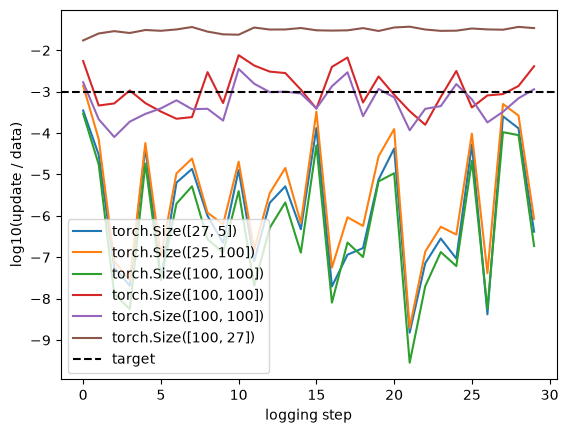

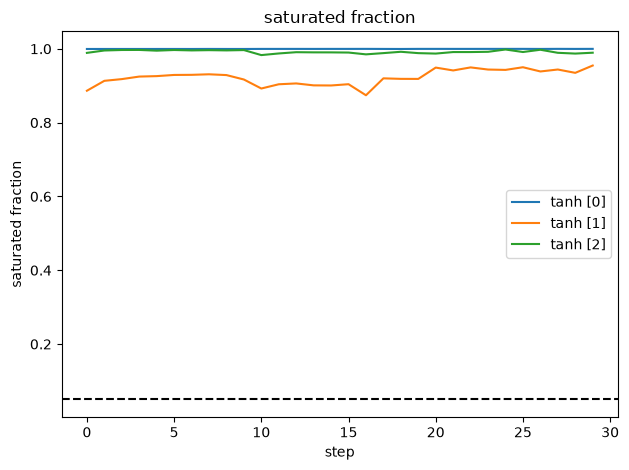

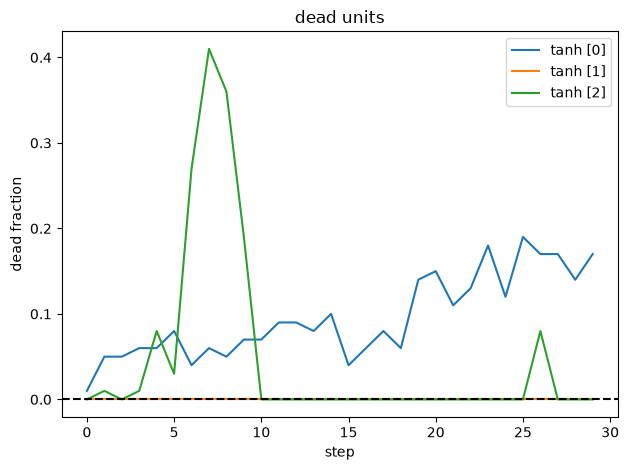

model=[Embedding: shape(torch.Size([27, 5])), Linear: weights: torch.Size([25, 100]) bias: torch.Size([100]), Linear: weights: torch.Size([100, 100]) bias: None, Tanh, Linear: weights: torch.Size([100, 100]) bias: None, Tanh, Linear: weights: torch.Size([100, 100]) bias: None, Tanh, Linear: weights: torch.Size([100, 27]) bias: torch.Size([27])]
epoch=0: epoch_loss=3.7029463346696074, dev_loss=tensor(2.8450)
epoch=1: epoch_loss=2.8146174590406146, dev_loss=tensor(2.8100)
epoch=2: epoch_loss=2.776327410985277, dev_loss=tensor(2.7858)
epoch=3: epoch_loss=3.0123881188161494, dev_loss=tensor(2.8865)
epoch=4: epoch_loss=2.938556899191496, dev_loss=tensor(2.9292)
epoch=5: epoch_loss=2.9384008998496203, dev_loss=tensor(3.0051)
epoch=6: epoch_loss=2.9004385715532788, dev_loss=tensor(2.8544)
epoch=7: epoch_loss=2.8714069680388206, dev_loss=tensor(2.8804)
epoch=8: epoch_loss=2.8321416912393294, dev_loss=tensor(2.8261)
epoch=9: epoch_loss=2.855244058928796, dev_loss=tensor(2.8766)
epoch=10: epoch_

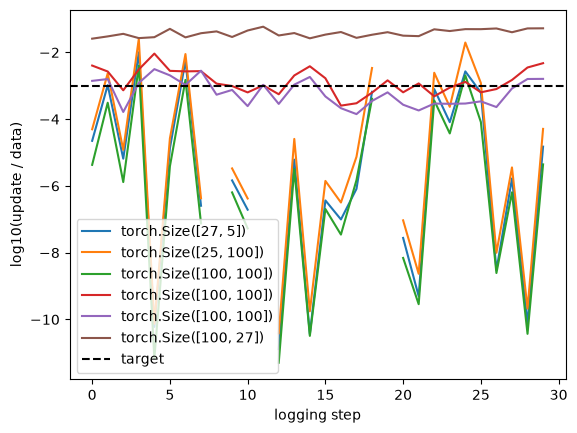

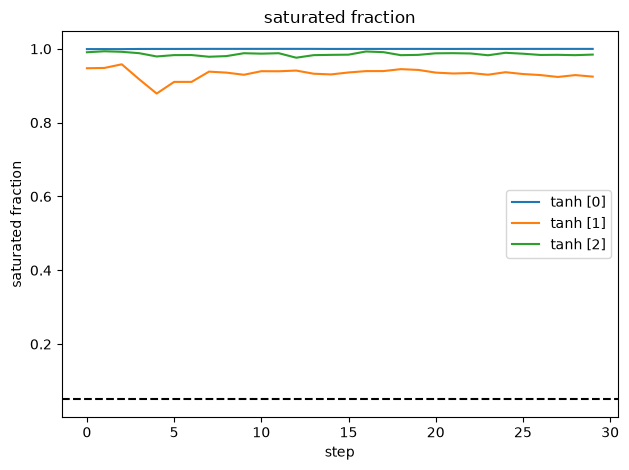

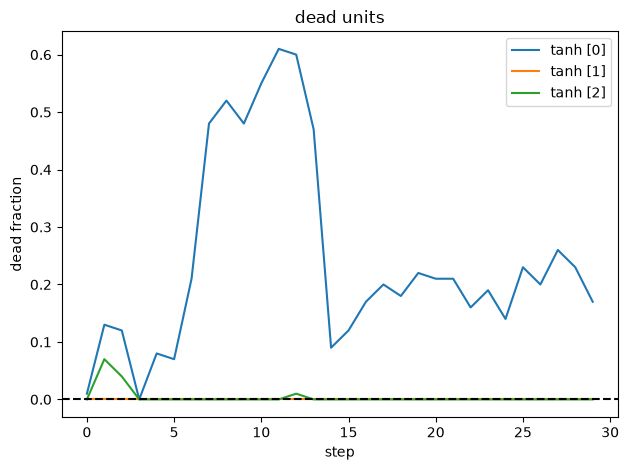

model=[Embedding: shape(torch.Size([27, 5])), Linear: weights: torch.Size([25, 100]) bias: None, BatchNorm1d: self.gamma.shape=torch.Size([100]), self.beta.shape=torch.Size([100]), Linear: weights: torch.Size([100, 100]) bias: None, BatchNorm1d: self.gamma.shape=torch.Size([100]), self.beta.shape=torch.Size([100]), Tanh, Linear: weights: torch.Size([100, 100]) bias: None, BatchNorm1d: self.gamma.shape=torch.Size([100]), self.beta.shape=torch.Size([100]), Tanh, Linear: weights: torch.Size([100, 100]) bias: None, BatchNorm1d: self.gamma.shape=torch.Size([100]), self.beta.shape=torch.Size([100]), Tanh, Linear: weights: torch.Size([100, 27]) bias: torch.Size([27]), BatchNorm1d: self.gamma.shape=torch.Size([27]), self.beta.shape=torch.Size([27])]
epoch=0: epoch_loss=2.5936439231336013, dev_loss=tensor(2.4491)
epoch=1: epoch_loss=2.4126868386387366, dev_loss=tensor(2.3668)
epoch=2: epoch_loss=2.3602828547562353, dev_loss=tensor(2.3227)
epoch=3: epoch_loss=2.324604572475437, dev_loss=tensor(2

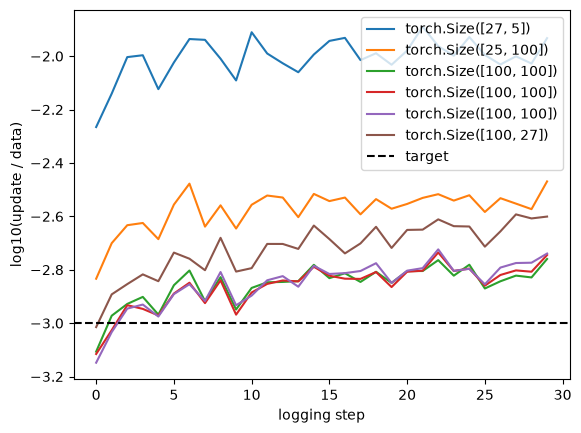

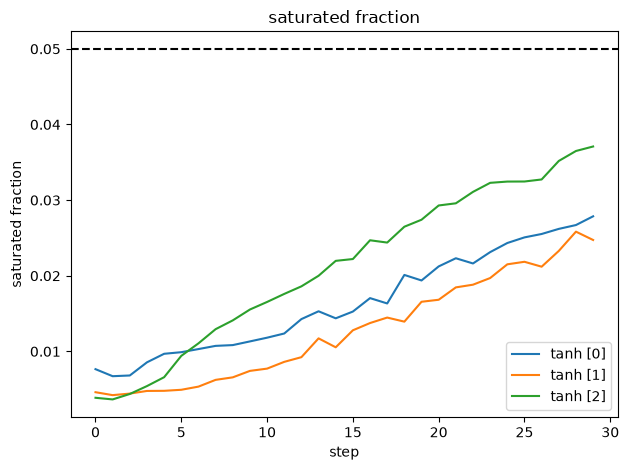

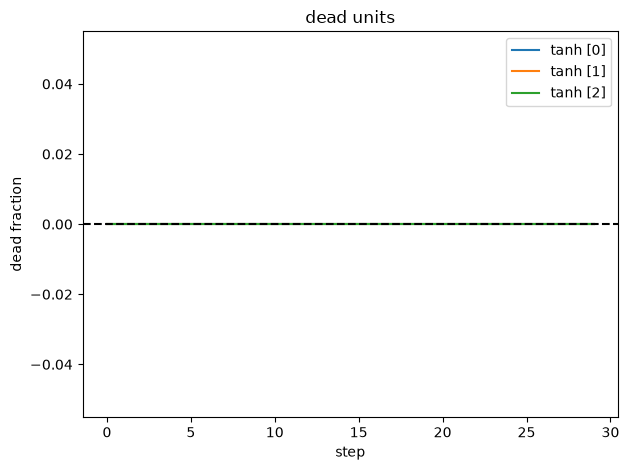

model=[Embedding: shape(torch.Size([27, 5])), Linear: weights: torch.Size([25, 100]) bias: None, BatchNorm1d: self.gamma.shape=torch.Size([100]), self.beta.shape=torch.Size([100]), Linear: weights: torch.Size([100, 100]) bias: None, BatchNorm1d: self.gamma.shape=torch.Size([100]), self.beta.shape=torch.Size([100]), Tanh, Linear: weights: torch.Size([100, 100]) bias: None, BatchNorm1d: self.gamma.shape=torch.Size([100]), self.beta.shape=torch.Size([100]), Tanh, Linear: weights: torch.Size([100, 100]) bias: None, BatchNorm1d: self.gamma.shape=torch.Size([100]), self.beta.shape=torch.Size([100]), Tanh, Linear: weights: torch.Size([100, 27]) bias: torch.Size([27]), BatchNorm1d: self.gamma.shape=torch.Size([27]), self.beta.shape=torch.Size([27])]
epoch=0: epoch_loss=2.4757061679084775, dev_loss=tensor(2.3388)
epoch=1: epoch_loss=2.3208446898656074, dev_loss=tensor(2.2753)
epoch=2: epoch_loss=2.279864444602209, dev_loss=tensor(2.2468)
epoch=3: epoch_loss=2.2564946477432413, dev_loss=tensor(2

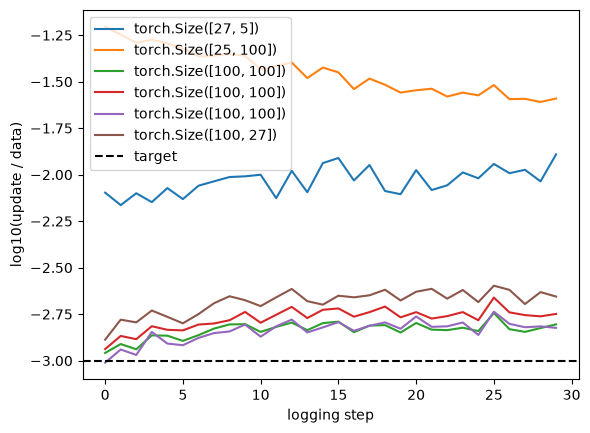

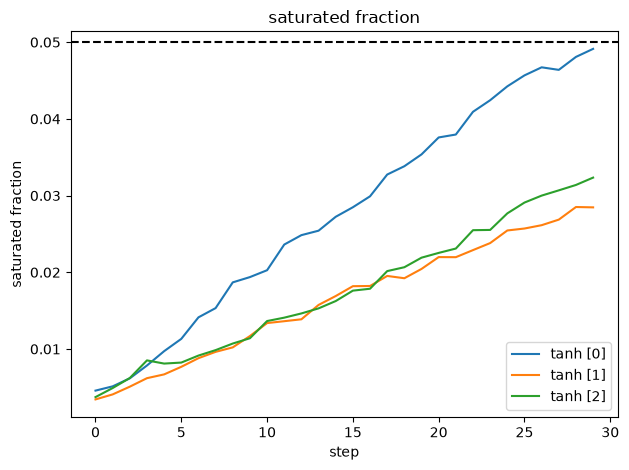

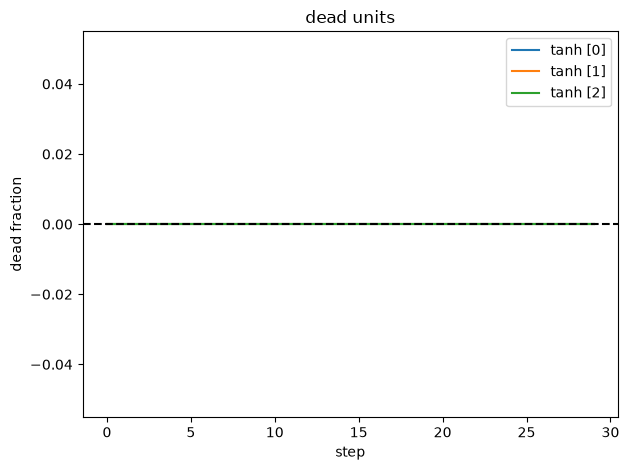

In [44]:
num_layers = 4
hidden_layer_sizes = [100] * num_layers
num_embedding_dims = 5
lr = 0.1
num_epochs = 30
batch_size = 64

best_dev_loss = float('inf')
best_config = None

print(f"==== Starting training with {num_embedding_dims=} dims and {hidden_layer_sizes=} ====")

# Neither normalization nor batch norm
model = Network(alphabet_len, num_prefix_chars, num_embedding_dims, hidden_layer_sizes, normalize=False, batchNorm=False) 
print(f"{model=}")

_, diagnostics = train(model, num_epochs, lr, batch_size)
plot_ud_ratio(model, diagnostics["ud_ratio"])
plot_layer_metric(model, diagnostics["saturation"], "saturated fraction", "saturated fraction", target=0.05)
plot_layer_metric(model, diagnostics["dead"], "dead units", "dead fraction", target=0.0)

# Just normalization
model = Network(alphabet_len, num_prefix_chars, num_embedding_dims, hidden_layer_sizes, normalize=True, batchNorm=False) 
print(f"{model=}")

_, diagnostics = train(model, num_epochs, lr, batch_size)
plot_ud_ratio(model, diagnostics["ud_ratio"])
plot_layer_metric(model, diagnostics["saturation"], "saturated fraction", "saturated fraction", target=0.05)
plot_layer_metric(model, diagnostics["dead"], "dead units", "dead fraction", target=0.0)

# Just batch norm
model = Network(alphabet_len, num_prefix_chars, num_embedding_dims, hidden_layer_sizes, normalize=False) 
print(f"{model=}")

_, diagnostics = train(model, num_epochs, lr, batch_size)
plot_ud_ratio(model, diagnostics["ud_ratio"])
plot_layer_metric(model, diagnostics["saturation"], "saturated fraction", "saturated fraction", target=0.05)
plot_layer_metric(model, diagnostics["dead"], "dead units", "dead fraction", target=0.0)

# Both
model = Network(alphabet_len, num_prefix_chars, num_embedding_dims, hidden_layer_sizes) 
print(f"{model=}")

_, diagnostics = train(model, num_epochs, lr, batch_size)
plot_ud_ratio(model, diagnostics["ud_ratio"])
plot_layer_metric(model, diagnostics["saturation"], "saturated fraction", "saturated fraction", target=0.05)
plot_layer_metric(model, diagnostics["dead"], "dead units", "dead fraction", target=0.0)